# Human-Mammalian Brain - Basal Ganglia Patchseq gene expression

You need to be connected to the internet to run this notebook and have run through the [getting started notebook](https://alleninstitute.github.io/abc_atlas_access/notebooks/getting_started.html).

In [1]:
import json
from typing import List, Tuple, Optional

import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache
from abc_atlas_access.abc_atlas_cache.anndata_utils import get_gene_data

We will interact with the data using the **AbcProjectCache**. This cache object tracks which data has been downloaded and serves the path to the requested data on disk. For metadata, the cache can also directly serve a up a Pandas DataFrame. See the [``getting_started``](https://alleninstitute.github.io/abc_atlas_access/notebooks/getting_started.html) notebook for more details on using the cache including installing the cache if it has not already been.

**Change the download_base variable to where you would like to download the data in your system.**

In [2]:
download_base = Path('../../data/abc_atlas')
abc_cache = AbcProjectCache.from_cache_dir(
    download_base,
    s3_bucket='allen-brain-cell-atlas-staging',
    auth_required=True
)

abc_cache.current_manifest

'releases/20250930/manifest.json'

## Cell metadata

In [3]:
abc_cache.list_directories

['ASAP-PMDBS-10X',
 'ASAP-PMDBS-taxonomy',
 'Allen-CCF-2020',
 'HMBA-10xMultiome-BG',
 'HMBA-10xMultiome-BG-Aligned',
 'HMBA-BG-taxonomy-CCN20250428',
 'HMBA-MERFISH-C57BL6J-638850-BG',
 'HMBA-MERSCOPE-H22.30.001-BG',
 'HMBA-MERSCOPE-QM23.50.001-BG',
 'HMBA-Macaque-PatchSeq',
 'HMBA-Xenium-CJ23.56.004-BG',
 'HMBA-Zhuang-ABCA-BG',
 'MERFISH-C57BL6J-638850',
 'MERFISH-C57BL6J-638850-CCF',
 'MERFISH-C57BL6J-638850-imputed',
 'MERFISH-C57BL6J-638850-sections',
 'SEAAD-taxonomy',
 'WHB-10Xv3',
 'WHB-taxonomy',
 'WMB-10X',
 'WMB-10XMulti',
 'WMB-10Xv2',
 'WMB-10Xv3',
 'WMB-neighborhoods',
 'WMB-taxonomy',
 'Zeng-Aging-Mouse-10Xv3',
 'Zeng-Aging-Mouse-WMB-taxonomy',
 'Zhuang-ABCA-1',
 'Zhuang-ABCA-1-CCF',
 'Zhuang-ABCA-2',
 'Zhuang-ABCA-2-CCF',
 'Zhuang-ABCA-3',
 'Zhuang-ABCA-3-CCF',
 'Zhuang-ABCA-4',
 'Zhuang-ABCA-4-CCF',
 'mmc-gene-mapper']

In [4]:
macaque_cell_metadata = abc_cache.get_metadata_dataframe(
    directory='HMBA-Macaque-PatchSeq',
    file_name='cell_metadata',
    dtype={"cell_label": str}
).set_index('cell_label')

macaque_donor = abc_cache.get_metadata_dataframe(
    directory='HMBA-Macaque-PatchSeq',
    file_name='donor'
).set_index('donor_label')

macaque_library = abc_cache.get_metadata_dataframe(
    directory='HMBA-Macaque-PatchSeq',
    file_name='library'
).set_index('library_label')

macaque_cell_metadata = macaque_cell_metadata.join(macaque_donor, on='donor_label', rsuffix='_donor')
macaque_cell_metadata = macaque_cell_metadata.join(macaque_library, on='library_label', rsuffix='_library')
macaque_cell_metadata

,library_label,library_aliquot_label,barcoded_cell_sample_label,donor_label,dataset_label,feature_matrix_label,donor_age_value,donor_age_unit,age_at_death_reference_point,donor_age,...,species_scientific_name,library_technique,library_aliquot_label_library,barcoded_cell_sample_label_library,barcoded_cell_sample_technique,amplified_cdna_label,tissue_sample_local_name,roi_id,roi_label,donor_label_library
cell_label,,,,,,,,,,,,,,,,,,,,,
QN22.26.002.14.05.04,L8S4_220222_04_H05,AB-S40302_S424_E1-50,P4S4_220131_155_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,Macaca nemestrina,SMARTSeqSC,AB-S40302_S424_E1-50,P4S4_220131_155_A01,PatchSeq-SmartSeq,A8S4_220215_06_H05,QN22.26.002.14.05,DHBA:10334,Ca,QN22.26.002
QN22.26.002.14.05.05,L8S4_220222_04_A06,AB-S40302_S425_E1-50,P4S4_220131_156_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,Macaca nemestrina,SMARTSeqSC,AB-S40302_S425_E1-50,P4S4_220131_156_A01,PatchSeq-SmartSeq,A8S4_220215_06_A06,QN22.26.002.14.05,DHBA:10334,Ca,QN22.26.002
QN22.26.002.14.05.06,L8S4_220222_04_B06,AB-S40302_S426_E1-50,P4S4_220131_157_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,Macaca nemestrina,SMARTSeqSC,AB-S40302_S426_E1-50,P4S4_220131_157_A01,PatchSeq-SmartSeq,A8S4_220215_06_B06,QN22.26.002.14.05,DHBA:10334,Ca,QN22.26.002
QN22.26.002.14.05.08,L8S4_220222_04_C06,AB-S40302_S427_E1-50,P4S4_220131_158_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,Macaca nemestrina,SMARTSeqSC,AB-S40302_S427_E1-50,P4S4_220131_158_A01,PatchSeq-SmartSeq,A8S4_220215_06_C06,QN22.26.002.14.05,DHBA:10334,Ca,QN22.26.002
QN22.26.002.14.05.09,L8S4_220222_04_D06,AB-S40302_S428_E1-50,P4S4_220131_159_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,Macaca nemestrina,SMARTSeqSC,AB-S40302_S428_E1-50,P4S4_220131_159_A01,PatchSeq-SmartSeq,A8S4_220215_06_D06,QN22.26.002.14.05,DHBA:10334,Ca,QN22.26.002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
QN21.26.031.12.02.03,L8S4_211213_02_C11,SM-LNJMY_S467_E1-50,PNS4_211122_852_A01,QN21.26.031,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,7,years,birth,7 yrs,...,Macaca nemestrina,SMARTSeqSC,SM-LNJMY_S467_E1-50,PNS4_211122_852_A01,PatchSeq-SmartSeq,A8S4_211130_06_C11,QN21.26.031.12.02,DHBA:10338,Pu,QN21.26.031
QN21.26.031.12.02.06,L8S4_211213_02_E11,SM-LNJMY_S469_E1-50,PNS4_211122_854_A01,QN21.26.031,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,7,years,birth,7 yrs,...,Macaca nemestrina,SMARTSeqSC,SM-LNJMY_S469_E1-50,PNS4_211122_854_A01,PatchSeq-SmartSeq,A8S4_211130_06_E11,QN21.26.031.12.02,DHBA:10338,Pu,QN21.26.031
QN21.26.031.12.01.01,L8S4_211213_02_H11,SM-LNJMY_S472_E1-50,PRS4_211122_253_A01,QN21.26.031,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,7,years,birth,7 yrs,...,Macaca nemestrina,SMARTSeqSC,SM-LNJMY_S472_E1-50,PRS4_211122_253_A01,PatchSeq-SmartSeq,A8S4_211130_06_H11,QN21.26.031.12.01,DHBA:10334,Ca,QN21.26.031


## Gene expression data

Now we can extract expression for specific genes from the h5ad files and pair it with our gene metadata. In general, we can use the function `get_gene_data` to extract the expression of specific genes for all the cells in a given dataset or a subset of cells.. For more details on using this convenience function, see the [Accessing 10x RNA-seq gene expression data](https://alleninstitute.github.io/abc_atlas_access/notebooks/general_accessing_10x_snRNASeq_tutorial.html) tutorial notebook.

For this tutorial we will use precomputed tables of the expression for specific genes to compare expression both spatially and by the taxonomy.

To use the gene expression data, we first load the set of genes for each of the 3 species in HMBA-BG.

In [5]:
macaque_genes = abc_cache.get_metadata_dataframe(
    directory='HMBA-Macaque-PatchSeq',
    file_name='gene',
).set_index('gene_identifier')
macaque_genes.head()

,gene_symbol,molecular_type,gene_name,description
gene_identifier,,,,
NCBIGene:712737,A1BG,protein_coding,A1BG,alpha-1-B glycoprotein
NCBIGene:703806,A1CF,protein_coding,A1CF,APOBEC1 complementation factor
NCBIGene:716616,A2ML1,protein_coding,A2ML1,alpha-2-macroglobulin like 1
NCBIGene:711045,A3GALT2,protein_coding,A3GALT2,"alpha 1,3-galactosyltransferase 2"
NCBIGene:710998,A4GALT,protein_coding,A4GALT,"alpha 1,4-galactosyltransferase"


In [6]:
gene_names = ['AQP4', 'DRD1', 'DRD2', 'SLC17A6']

In [7]:
macaque_gene_data = get_gene_data(
    abc_atlas_cache=abc_cache,
    all_cells=macaque_cell_metadata,
    all_genes=macaque_genes,
    selected_genes=gene_names,
    data_type='log2'
)

loading file: HMBA-Macaque-PatchSeq-BG
 - time taken:  0.12122399999999978
total time taken: 0.1223080000000003
	total cells: 876 processed cells: 876


In [8]:
macaque_gene_data

gene_symbol,AQP4,DRD1,DRD2,SLC17A6
cell_label,,,,
QN22.26.002.14.05.04,0.0,0.0,8.153246,0.0
QN22.26.002.14.05.05,3.427291,6.759345,0.0,0.0
QN22.26.002.14.05.06,0.0,0.0,7.467582,0.0
QN22.26.002.14.05.08,0.0,0.0,7.258967,0.0
QN22.26.002.14.05.09,0.0,8.067217,0.0,0.0
...,...,...,...,...
QN21.26.031.12.02.03,0.0,0.0,3.046777,0.0
QN21.26.031.12.02.06,0.0,0.0,2.628689,1.844916
QN21.26.031.12.01.01,7.362209,0.0,0.0,0.0


Now that we've loaded our expression matrix tables, indexed by cell_label, we can merge them into our cell metadata tables.

In [9]:
macaque_cell_metadata_with_genes = macaque_cell_metadata.join(macaque_gene_data, on='cell_label')

### Plotting heatmap expression data.

We define a helper functions *aggregate_by_metadata* to compute the average expression for a given category. Note that this is a simple wrapper of the Pandas GroupBy functionality. Other summary statistics beyond just the `mean` are listed here: https://pandas.pydata.org/docs/reference/groupby.html#dataframegroupby-computations-descriptive-stats

We also define a function to plot the resultant averaged data in a heatmap.

In [10]:
def aggregate_by_metadata(df: pd.DataFrame, gnames: List[str], value: str, sort: bool = False) -> pd.DataFrame:
    """Aggregate gene expression data by metadata.

    Parameters
    ----------
    df: pandas.DataFrame
        DataFrame containing gene expression and metadata.
    gnames: List[str]
        List of gene names to aggregate.
    value: str
    sort: bool
        Metadata column to group by.
        If True, sort the output by the first gene in gnames.

    Returns
    -------
    pandas.DataFrame
        DataFrame with aggregated gene expression values.
    """
    grouped = df.groupby(value)[gnames].mean()
    if sort:
        grouped = grouped.sort_values(by=gnames[0], ascending=False)
    return grouped


def plot_heatmap(
        df: pd.DataFrame,
        fig_width: int = 8,
        fig_height: int = 4,
        cmap: mpl.colormaps = plt.cm.magma,
        vmax: Optional[float] = None,
        unit: str = '[log2(CPM + 1)]'
    ) -> Tuple[plt.Figure, plt.Axes]:
    """Plot a heatmap from a DataFrame.

    Parameters
    ----------
    df: pandas.DataFrame
        DataFrame to plot as a heatmap.
    fig_width: int
        Width of the figure.
    fig_height: int
        Height of the figure.
    cmap: matplotlib.colors.Colormap
        Colormap to use for the heatmap.

    Returns
    -------
    fig: matplotlib.pyplot.Figure
        Figure object containing the heatmap.
    ax: matplotlib.pyplot.Axes
        Axes object containing the heatmap.
    """

    arr = df.to_numpy().astype('float')

    vmin = arr.min()
    vmax = arr.max()
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cmap = sm.get_cmap()

    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)

    ax.imshow(arr, cmap=cmap, aspect='auto')
    xlabs = df.columns.values
    ylabs = df.index.values

    ax.set_xticks(range(len(xlabs)))
    ax.set_xticklabels(xlabs)

    ax.set_yticks(range(len(ylabs)))
    ax.set_yticklabels(ylabs)

    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.1, pad=0.01)
    cbar.set_label(unit)

    return fig, ax

### Visualize gene expression for selected genes by ROI

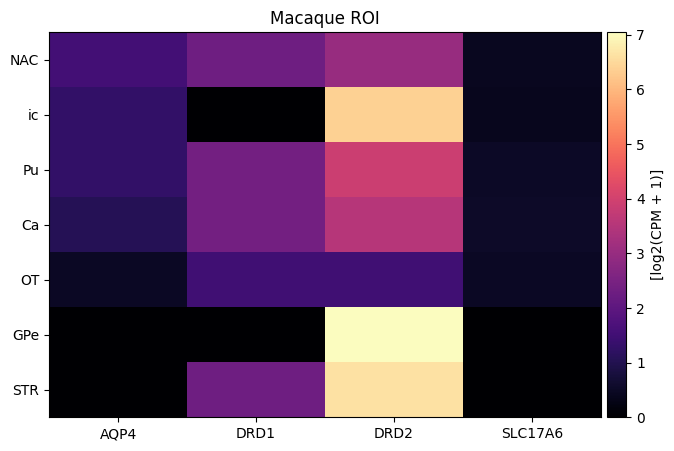

In [11]:
macaque_gene_names = macaque_cell_metadata_with_genes.columns[
    macaque_cell_metadata_with_genes.columns.isin(gene_names)
].to_numpy()
agg = aggregate_by_metadata(macaque_cell_metadata_with_genes, macaque_gene_names, 'roi_label', sort=True)
plot_heatmap(agg, 8, 5)
plt.title('Macaque ROI')
plt.show()

## Taxonomy mapping

Finally, let's load the taxonomy information so that we can plot gene expression versus various taxons in a heatmap for each species. Below, we load and merge all the information we need to plot cell colors and taxonomy as done in previous [HMBA tutorial](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_bg_clustering_analysis_and_annotation.html).

In [12]:
cluster = abc_cache.get_metadata_dataframe(
    directory='HMBA-BG-taxonomy-CCN20250428',
    file_name='cluster',
    dtype={'number_of_cells': 'Int64'}
).rename(columns={'label': 'cluster_annotation_term_label'}).set_index('cluster_annotation_term_label')
cluster_annotation_term_set = abc_cache.get_metadata_dataframe(
    directory='HMBA-BG-taxonomy-CCN20250428',
    file_name='cluster_annotation_term_set'
).rename(columns={'label': 'cluster_annotation_term_label'})

cluster_annotation_term = abc_cache.get_metadata_dataframe(
    directory='HMBA-BG-taxonomy-CCN20250428',
    file_name='cluster_annotation_term',
).rename(columns={'label': 'cluster_annotation_term_label'}).set_index('cluster_annotation_term_label')

cluster_to_cluster_annotation_membership = abc_cache.get_metadata_dataframe(
    directory='HMBA-BG-taxonomy-CCN20250428',
    file_name='cluster_to_cluster_annotation_membership',
).set_index('cluster_annotation_term_label')
membership_with_cluster_info = cluster_to_cluster_annotation_membership.join(
    cluster.reset_index().set_index('cluster_alias')[['number_of_cells']],
    on='cluster_alias'
)
membership_with_cluster_info = membership_with_cluster_info.join(cluster_annotation_term, rsuffix='_anno_term').reset_index()
membership_groupby = membership_with_cluster_info.groupby(
    ['cluster_alias', 'cluster_annotation_term_set_name']
)

cluster_annotation_term_set = abc_cache.get_metadata_dataframe(
    directory='HMBA-BG-taxonomy-CCN20250428',
    file_name='cluster_annotation_term_set'
).rename(columns={'label': 'cluster_annotation_term_label'})

# term_sets = abc_cache.get_metadata_dataframe(directory='WHB-taxonomy', file_name='cluster_annotation_term_set').set_index('label')
cluster_details = membership_groupby['cluster_annotation_term_name'].first().unstack()
cluster_order = membership_groupby['term_order'].first().unstack()
cluster_order.sort_values(['Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster'], inplace=True)
cluster_order.rename(
    columns={'Neighborhood': 'Neighborhood_order',
             'Class': 'Class_order',
             'Subclass': 'Subclass_order',
             'Group': 'Group_order',
             'Cluster': 'Cluster_order'},
    inplace=True
)

cluster_colors = membership_groupby['color_hex_triplet'].first().unstack()
cluster_colors = cluster_colors[cluster_annotation_term_set['name']]
cluster_colors.sort_values(
    ['Neighborhood', 'Class', 'Subclass', 'Group', 'Cluster'],
    inplace=True
)

Each of the three species gene expression has been mapped to the HMBA 10X taxonomy using MapMyCells. Below we load the mapping of each cell to the cluster it was assigned data for each species in the HMBA-BG dataset.

In [13]:
abc_cache.list_metadata_files(
    directory='HMBA-Macaque-PatchSeq',
)

['ap_features',
 'cell_metadata',
 'chrip_features',
 'cross_sweep_long_square_features',
 'donor',
 'gene',
 'library',
 'mmc_hmba-bg-20250428_taxonomy_mapping',
 'sweep_features']

In [14]:
macaque_mmc = abc_cache.get_metadata_dataframe(
    directory='HMBA-Macaque-PatchSeq',
    file_name='mmc_hmba-bg-20250428_taxonomy_mapping',
).set_index('cell_label').rename(columns={'Cluster_alias': 'cluster_alias'})
macaque_mmc

,Neighborhood_label,Neighborhood_name,Neighborhood_bootstrapping_probability,Neighborhood_aggregate_probability,Neighborhood_correlation_coefficient,Class_label,Class_name,Class_bootstrapping_probability,Class_aggregate_probability,Class_correlation_coefficient,...,Group_label,Group_name,Group_bootstrapping_probability,Group_aggregate_probability,Group_correlation_coefficient,Cluster_label,cluster_alias,Cluster_bootstrapping_probability,Cluster_aggregate_probability,Cluster_correlation_coefficient
cell_label,,,,,,,,,,,,,,,,,,,,,
QN22.26.002.14.05.04,CS20250428_NEIGH_0002,Subpallium GABA,1.0,1.0,0.7190,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.00,0.7093,...,CS20250428_GROUP_0054,STRd D2 Striosome MSN,1.00,1.0000,0.5715,CS20250428_CLUST_0986,Macaque-429,1.00,1.0000,0.5615
QN22.26.002.14.05.05,CS20250428_NEIGH_0002,Subpallium GABA,1.0,1.0,0.7634,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.00,0.7466,...,CS20250428_GROUP_0049,STRd D1 Matrix MSN,1.00,1.0000,0.6477,CS20250428_CLUST_0949,Macaque-467,0.99,0.9900,0.5517
QN22.26.002.14.05.06,CS20250428_NEIGH_0002,Subpallium GABA,1.0,1.0,0.6603,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.00,0.6376,...,CS20250428_GROUP_0054,STRd D2 Striosome MSN,1.00,1.0000,0.4564,CS20250428_CLUST_0986,Macaque-429,0.62,0.6200,0.4341
QN22.26.002.14.05.08,CS20250428_NEIGH_0002,Subpallium GABA,1.0,1.0,0.6162,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.00,0.5980,...,CS20250428_GROUP_0052,STRd D2 Matrix MSN,0.88,0.8800,0.4317,CS20250428_CLUST_0973,Macaque-465,1.00,0.8800,0.4515
QN22.26.002.14.05.09,CS20250428_NEIGH_0002,Subpallium GABA,1.0,1.0,0.6987,CS20250428_CLASS_0003,CN LGE GABA,1.00,1.00,0.6847,...,CS20250428_GROUP_0049,STRd D1 Matrix MSN,0.99,0.9900,0.5025,CS20250428_CLUST_0949,Macaque-467,0.57,0.5643,0.3415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
QN21.26.031.12.02.03,CS20250428_NEIGH_0002,Subpallium GABA,1.0,1.0,0.4734,CS20250428_CLASS_0006,F M GABA,1.00,1.00,0.4454,...,CS20250428_GROUP_0066,AMY-SLEA-BNST GABA,1.00,1.0000,0.3725,CS20250428_CLUST_0607,Macaque-25,1.00,1.0000,0.4058
QN21.26.031.12.02.06,CS20250428_NEIGH_0002,Subpallium GABA,1.0,1.0,0.5005,CS20250428_CLASS_0006,F M GABA,0.99,0.99,0.4643,...,CS20250428_GROUP_0066,AMY-SLEA-BNST GABA,0.94,0.9306,0.3206,CS20250428_CLUST_0607,Macaque-25,1.00,0.9306,0.4082
QN21.26.031.12.01.01,CS20250428_NEIGH_0002,Subpallium GABA,1.0,1.0,0.4681,CS20250428_CLASS_0006,F M GABA,1.00,1.00,0.4573,...,CS20250428_GROUP_0066,AMY-SLEA-BNST GABA,1.00,1.0000,0.3230,CS20250428_CLUST_0607,Macaque-25,1.00,1.0000,0.3550


In [15]:
macaque_cell_metadata_with_genes = macaque_cell_metadata_with_genes.join(macaque_mmc)
macaque_cell_metadata_with_genes = macaque_cell_metadata_with_genes.join(cluster_details, on='cluster_alias')
macaque_cell_metadata_with_genes = macaque_cell_metadata_with_genes.join(cluster_colors, on='cluster_alias', rsuffix='_color')
macaque_cell_metadata_with_genes = macaque_cell_metadata_with_genes.join(cluster_order, on='cluster_alias')

macaque_cell_metadata_with_genes.head()

,library_label,library_aliquot_label,barcoded_cell_sample_label,donor_label,dataset_label,feature_matrix_label,donor_age_value,donor_age_unit,age_at_death_reference_point,donor_age,...,Neighborhood_color,Class_color,Subclass_color,Group_color,Cluster_color,Class_order,Cluster_order,Group_order,Neighborhood_order,Subclass_order
cell_label,,,,,,,,,,,,,,,,,,,,,
QN22.26.002.14.05.04,L8S4_220222_04_H05,AB-S40302_S424_E1-50,P4S4_220131_155_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,#19613b,#d0b83c,#253c8c,#ff9896,#561430,10,1290,55,3,32
QN22.26.002.14.05.05,L8S4_220222_04_A06,AB-S40302_S425_E1-50,P4S4_220131_156_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,#19613b,#d0b83c,#1655f2,#1f77b4,#b83642,10,1059,50,3,31
QN22.26.002.14.05.06,L8S4_220222_04_B06,AB-S40302_S426_E1-50,P4S4_220131_157_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,#19613b,#d0b83c,#253c8c,#ff9896,#561430,10,1290,55,3,32
QN22.26.002.14.05.08,L8S4_220222_04_C06,AB-S40302_S427_E1-50,P4S4_220131_158_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,#19613b,#d0b83c,#253c8c,#aec7e8,#d71b39,10,1194,53,3,32
QN22.26.002.14.05.09,L8S4_220222_04_D06,AB-S40302_S428_E1-50,P4S4_220131_159_A01,QN22.26.002,HMBA-Macaque-PatchSeq,HMBA-Macaque-PatchSeq-BG,15,years,birth,15 yrs,...,#19613b,#d0b83c,#1655f2,#1f77b4,#b83642,10,1059,50,3,31


### Visualize gene expression for selected genes by the HMBA-BG taxonomy.

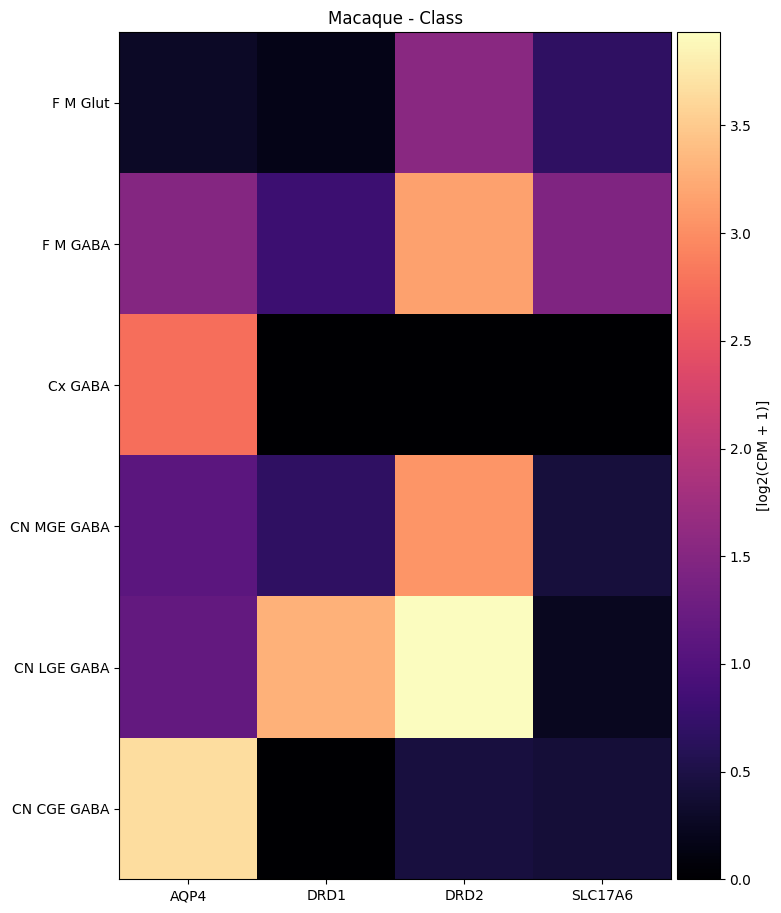

In [16]:
macaque_gene_names = macaque_cell_metadata_with_genes.columns[
    macaque_cell_metadata_with_genes.columns.isin(gene_names)
].to_numpy()
agg = aggregate_by_metadata(macaque_cell_metadata_with_genes, macaque_gene_names, 'Class')
agg = agg.loc[list(reversed(list(agg.index)))]
plot_heatmap(agg, 8, 11, vmax=15)
plt.title('Macaque - Class')
plt.show()

To learn more about the spatial data see the [HBMA-BG Spatial Slabs and Taxonomy notebook](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_bg_spatial_slabs_and_taxonomy.html).

To learn more about the taxonomy used in this notebook and the data it is derived from, see the [HMBA-BG Clustering Analysis and Taxonomy notebook](https://alleninstitute.github.io/abc_atlas_access/notebooks/hmba_bg_clustering_analysis_and_annotation.html).